
# Masked diffusion models for discrete tokens

This notebook is a compact teaching demo for **masked diffusion** in the discrete-token setting.

It has two goals:

1. explain the basic idea behind masking-based discrete diffusion,
2. show two small practical experiments that run on a laptop or a Mac:
   - a **synthetic mirror-sequence** task,
   - a **short text generation** task with **32-token sequences**.

The code is intentionally small and readable. It uses a tiny Transformer denoiser plus an absorbing **`[MASK]`** corruption process.



## What to tell students before running the code

A masked diffusion model for tokens works like this:

- Start from a clean sequence $x_0$.
- Corrupt it by replacing some tokens with a special **mask token**.
- Train a model to predict the original clean tokens from the partially masked sequence.
- At generation time, start from an almost fully masked sequence and **iteratively unmask** it.

This notebook uses a **pedagogical variant** of masked diffusion:

- the forward process is an **absorbing-mask corruption process**,
- the reverse process uses **confidence-based progressive unmasking**.

That reverse sampler is simple and easy to visualize. It is closely related to masked discrete diffusion ideas and to iterative masked generation methods such as MaskGIT, while keeping the code short enough for a classroom notebook.



## Theory in one page

Let `m = [MASK]` denote a special **absorbing state**. A masked discrete diffusion model is defined by a forward Markov chain that gradually moves tokens into `m`.

For a discrete schedule with steps $0=t_0 < t_1 < \dots < t_T=1$, one forward step at position $i$ is

$$
q\!
\left(x_{t_k}^{(i)} \mid x_{t_{k-1}}^{(i)}\right)
=
\begin{cases}
\delta_m & \text{if } x_{t_{k-1}}^{(i)} = m,\\[4pt]
(1-\beta_k)\,\delta_{x_{t_{k-1}}^{(i)}} + \beta_k\,\delta_m & \text{if } x_{t_{k-1}}^{(i)} \neq m.
\end{cases}
$$

So once a token becomes masked, it stays masked forever. That is the discrete analogue of a diffusion process with an absorbing noise state.

After many such steps, the forward **marginal** has a very simple form:

$$
q\!\left(x_t^{(i)} \mid x_0^{(i)}\right)
=
\alpha_t \, \delta_{x_0^{(i)}} + (1-\alpha_t) \, \delta_m,
$$

where, in discrete time, $\alpha_t$ is the product of the survival probabilities $\prod_{j \le t}(1-\beta_j)$.

This is exactly the corruption rule used in the notebook: at noise level $t$, a token is still clean with probability $\alpha_t$ and is replaced by `[MASK]` with probability $1-\alpha_t$. The notebook uses the pedagogically simple choice

$$
\alpha_t = 1-t.
$$

The reverse model receives $(x_t, t)$ and predicts a distribution over the original clean tokens. Generation starts from an all-mask or almost-all-mask sequence and repeatedly applies reverse denoising steps.

This is a **real diffusion model** in the discrete setting because it has the same three ingredients as continuous DDPMs:

1. a fixed forward corruption process $q$,
2. a learned reverse process $p_\theta$,
3. a training objective derived from a variational lower bound (ELBO).

The key extra fact for masked diffusion is that, with the absorbing-mask process above, the ELBO becomes a weighted sum of masked-token cross-entropy terms. That is the exact bridge to masked language modeling.



## Derivation: why the diffusion loss becomes masked language modeling

Consider one reverse step from time $t$ to an earlier time $s<t$. The diffusion ELBO contains the term

$$
\mathcal{L}_{t\to s}
=
\mathbb{E}_{q(x_0) q(x_t\mid x_0)}
\left[
D_{\mathrm{KL}}\!\left(q(x_s\mid x_t, x_0)\;\|\; p_\theta(x_s\mid x_t)\right)
\right].
$$

Because the forward process factorizes over token positions, we can analyze one position $i$.

### Step 1: the reverse posterior has only two possibilities

There are only two cases.

If $x_t^{(i)} \neq m$, then the token has not yet been masked, so by the absorbing construction it must stay equal to the same visible token when we move backward from $t$ to $s$:

$$
q\!\left(x_s^{(i)} = x_t^{(i)} \mid x_t^{(i)} \neq m, x_0^{(i)}\right)=1.
$$

So visible tokens carry no uncertainty.

If $x_t^{(i)} = m$, then $x_s^{(i)}$ can only be either the clean token $x_0^{(i)}$ or the mask token $m$. A one-line Bayes calculation gives

$$
q\!\left(x_s^{(i)} = x_0^{(i)} \mid x_t^{(i)} = m, x_0^{(i)}\right)
=
\frac{\alpha_s - \alpha_t}{1-\alpha_t},
$$

$$
q\!\left(x_s^{(i)} = m \mid x_t^{(i)} = m, x_0^{(i)}\right)
=
\frac{1-\alpha_s}{1-\alpha_t}.
$$

A short proof of the first identity is:

$$
q\!\left(x_s^{(i)} = x_0^{(i)} \mid x_0^{(i)}\right) = \alpha_s,
\qquad
q\!\left(x_t^{(i)} = m \mid x_s^{(i)} = x_0^{(i)}\right) = 1-\frac{\alpha_t}{\alpha_s},
$$

and

$$
q\!\left(x_t^{(i)} = m \mid x_0^{(i)}\right)=1-\alpha_t.
$$

Therefore, by Bayes,

$$
q\!\left(x_s^{(i)} = x_0^{(i)} \mid x_t^{(i)}=m, x_0^{(i)}\right)
=
\frac{\left(1-\frac{\alpha_t}{\alpha_s}\right)\alpha_s}{1-\alpha_t}
=
\frac{\alpha_s-\alpha_t}{1-\alpha_t}.
$$

### Step 2: parameterize the reverse process by predicting the clean token

Let the model output a clean-token distribution

$$
\mu_\theta^{(i)}(x_t,t) \in \Delta^{|\mathcal{V}|},
$$

where $\mathcal{V}$ is the clean vocabulary without `[MASK]`. We then define the reverse model to have the **same family** as the true posterior:

- if a token is already visible, copy it through unchanged,
- if a token is masked, predict how much probability to assign to each possible clean token.

Under this parameterization, the only learnable part of the KL is the probability assigned to the true clean token. The per-position KL becomes

$$
D_{\mathrm{KL}}(q\;\|\;p_\theta)
=
-\mathbf{1}[x_t^{(i)} = m]
\frac{\alpha_s-\alpha_t}{1-\alpha_t}
\log \mu_\theta^{(i)}\!\left(x_0^{(i)} \mid x_t,t\right).
$$

This is exactly a masked-token cross-entropy term with a time-dependent scalar weight.

### Step 3: sum positions and take the continuous-time limit

Summing over positions gives

$$
\mathcal{L}_{t\to s}
=
\mathbb{E}
\left[
\sum_{i=1}^L
w_{t,s}
\,\mathbf{1}[x_t^{(i)}=m]
\,\mathrm{CE}\!\left(\delta_{x_0^{(i)}},\mu_\theta^{(i)}(x_t,t)\right)
\right],
\qquad
w_{t,s}=\frac{\alpha_s-\alpha_t}{1-\alpha_t}.
$$

In continuous time, the reverse-step sum becomes an integral:

$$
\mathcal{L}_{\infty}
=
\int_0^1
\frac{-\alpha_t'}{1-\alpha_t}
\;\mathbb{E}_{q(x_t\mid x_0)}
\left[
\sum_{i:x_t^{(i)}=m}
\mathrm{CE}\!\left(\delta_{x_0^{(i)}},\mu_\theta^{(i)}(x_t,t)\right)
\right]dt.
$$

So the masked diffusion ELBO is not merely *similar* to masked language modeling. For the absorbing-mask diffusion process, it is literally a **weighted mixture of MLM losses across noise levels**.



## What this means conceptually

A classical masked language model and a masked diffusion model share the same local denoising target: predict the original token only where the input is masked.

The diffusion viewpoint adds three pieces of structure:

- a full forward noising process indexed by time $t$,
- an ELBO that tells us exactly how to weight the denoising losses,
- a reverse-time sampler that turns the denoiser into a generator.

That is why a BERT-like MLM objective by itself is **not yet** a diffusion model, while absorbing masked diffusion is. Diffusion is "MLM + a forward process + a reverse chain + a principled generative interpretation".

### Relation to the code in this notebook

The training code uses the simpler classroom loss

$$
\widehat{\mathcal{L}}
=
\sum_{i=1}^L
\mathbf{1}[x_t^{(i)}=m]
\,\mathrm{CE}\!\left(\delta_{x_0^{(i)}},\mu_\theta^{(i)}(x_t,t)\right).
$$

This has the same form as the exact diffusion objective above, but it drops the explicit time weight
$\frac{-\alpha_t'}{1-\alpha_t}$.

For teaching, that simplification is useful:

- it keeps the code very short,
- it avoids over-emphasizing nearly clean examples,
- it still shows the core iterative-unmasking idea clearly.

For the linear schedule $\alpha_t = 1-t$ used here, the exact continuous-time weight would be

$$
\frac{-\alpha_t'}{1-\alpha_t} = \frac{1}{t}.
$$

So the notebook should be described as a **pedagogically simplified masked diffusion implementation** whose loss is the same masked-token cross-entropy form, but without the exact ELBO weighting over noise levels.

The Bayes-optimal conditional target at each noise level is unchanged; what changes is how much optimization effort is allocated to easy versus hard timesteps.


In [36]:

import os
import math
import random
from dataclasses import dataclass
from collections import Counter

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

if device.type == "cpu":
    torch.set_num_threads(min(4, os.cpu_count() or 1))

FAST_MODE = False
print(f"device = {device}")
print(f"FAST_MODE = {FAST_MODE}")


device = mps
FAST_MODE = False



## Shared model and utilities

We use the same tiny denoiser in both experiments:

- token embeddings,
- positional embeddings,
- a learned embedding of the noise level,
- a small Transformer encoder,
- a linear output head over the token vocabulary.

The sampling function below starts from a masked sequence and gradually reveals tokens.


In [37]:

class TinyMaskedDiffusionTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        seq_len,
        d_model=64,
        n_heads=4,
        n_layers=2,
        d_ff=128,
        dropout=0.1,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.time_mlp = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x_tokens, noise_level):
        batch_size, seq_len = x_tokens.shape
        positions = torch.arange(seq_len, device=x_tokens.device).unsqueeze(0)
        h = self.token_emb(x_tokens)
        h = h + self.pos_emb(positions)
        h = h + self.time_mlp(noise_level[:, None]).unsqueeze(1)
        h = self.encoder(h)
        h = self.norm(h)
        return self.head(h)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def corrupt_batch(
    x,
    mask_id,
    protect_prefix=0,
    min_mask_ratio=0.10,
    max_mask_ratio=1.00,
    fully_masked_prob=0.10,
):
    """
    Create x_t by replacing random positions with [MASK].

    protect_prefix:
        number of leading positions that should never be masked.
        We use this for the text demo so that <bos> stays visible.
    """
    batch_size, seq_len = x.shape
    noise = min_mask_ratio + (max_mask_ratio - min_mask_ratio) * torch.rand(batch_size, device=x.device)
    mask = torch.rand(batch_size, seq_len, device=x.device) < noise[:, None]

    if protect_prefix > 0:
        mask[:, :protect_prefix] = False

    # Force some fully masked examples so the model sees near-unconditional denoising.
    if fully_masked_prob > 0:
        force_full = torch.rand(batch_size, device=x.device) < fully_masked_prob
        if protect_prefix > 0:
            mask[force_full, protect_prefix:] = True
        else:
            mask[force_full] = True

    empty = mask.sum(dim=1) == 0
    if empty.any():
        rows = empty.nonzero(as_tuple=False).squeeze(-1)
        cols = torch.randint(protect_prefix, seq_len, (rows.numel(),), device=x.device)
        mask[rows, cols] = True

    x_t = x.clone()
    x_t[mask] = mask_id
    return x_t, noise, mask


def masked_cross_entropy(logits, target, mask):
    batch_size, seq_len, vocab_size = logits.shape
    per_token = nn.functional.cross_entropy(
        logits.reshape(batch_size * seq_len, vocab_size),
        target.reshape(-1),
        reduction="none",
    ).reshape(batch_size, seq_len)
    return (per_token * mask.float()).sum() / mask.float().sum().clamp_min(1.0)


def train_model(
    model,
    train_loader,
    val_loader,
    mask_id,
    epochs=8,
    lr=5e-4,
    protect_prefix=0,
):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_total = 0.0
        train_count = 0

        for batch in train_loader:
            batch = batch.to(device)
            x_t, noise, mask = corrupt_batch(batch, mask_id=mask_id, protect_prefix=protect_prefix)
            logits = model(x_t, noise)
            loss = masked_cross_entropy(logits, batch, mask)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_total += loss.item()
            train_count += 1

        model.eval()
        val_total = 0.0
        val_count = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                x_t, noise, mask = corrupt_batch(batch, mask_id=mask_id, protect_prefix=protect_prefix)
                logits = model(x_t, noise)
                loss = masked_cross_entropy(logits, batch, mask)
                val_total += loss.item()
                val_count += 1

        mean_train = train_total / max(train_count, 1)
        mean_val = val_total / max(val_count, 1)
        history["train_loss"].append(mean_train)
        history["val_loss"].append(mean_val)
        print(f"epoch {epoch + 1:02d} | train {mean_train:.4f} | val {mean_val:.4f}")

    return history


def plot_history(history, title):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("masked cross-entropy")
    plt.title(title)
    plt.legend()
    plt.show()


@torch.no_grad()
def progressive_unmask_sample(
    model,
    seq_len,
    mask_id,
    steps,
    fixed_tokens=None,
    temperature=1.0,
    greedy=False,
    banned_token_ids=None,
):
    """
    Simple confidence-based reverse process.

    - Start from mostly masked tokens.
    - Predict all masked positions.
    - Keep the most confident ones.
    - Re-mask the least confident ones until the final step.

    This is an easy-to-teach sampler for masked token diffusion / iterative refinement.
    """
    model.eval()
    x = torch.full((1, seq_len), mask_id, dtype=torch.long, device=device)
    fixed_mask = torch.zeros_like(x, dtype=torch.bool)

    if fixed_tokens is not None:
        for position, token_id in fixed_tokens.items():
            x[0, position] = token_id
            fixed_mask[0, position] = True

    history = [x[0].detach().cpu().clone()]
    initial_mask_count = int((x == mask_id).sum().item())

    for step in range(steps):
        masked_positions = x == mask_id
        noise_level = masked_positions.float().mean(dim=1)
        logits = model(x, noise_level)

        logits[:, :, mask_id] = -1e9
        if banned_token_ids is not None:
            for token_id in banned_token_ids:
                logits[:, :, token_id] = -1e9

        probs = torch.softmax(logits / temperature, dim=-1)
        if greedy:
            pred = logits.argmax(dim=-1)
        else:
            pred = torch.distributions.Categorical(probs).sample()

        confidence = probs.gather(-1, pred.unsqueeze(-1)).squeeze(-1)
        proposal = x.clone()
        proposal[masked_positions] = pred[masked_positions]

        if step == steps - 1:
            x = proposal
        else:
            current_masked = masked_positions[0].nonzero(as_tuple=False).squeeze(-1)
            if current_masked.numel() > 0:
                current_masked = current_masked[~fixed_mask[0, current_masked]]

            progress = (step + 1) / steps
            target_to_keep_masked = max(1, round(initial_mask_count * (1.0 - progress) ** 2))
            target_to_keep_masked = min(target_to_keep_masked, current_masked.numel())

            x = proposal
            if target_to_keep_masked > 0 and current_masked.numel() > 0:
                low_conf_idx = torch.topk(
                    confidence[0, current_masked],
                    k=target_to_keep_masked,
                    largest=False,
                ).indices
                low_conf_positions = current_masked[low_conf_idx]
                x[0, low_conf_positions] = mask_id

        history.append(x[0].detach().cpu().clone())

    return x[0].detach().cpu(), history



# Part 1 — Synthetic discrete sequences

We start with a tiny rule-based dataset:

$$[a, b, c, c, b, a]$$

where $a, b, c \in \{0,1,\dots,7\}$ are random digits.

This is useful for teaching because:

- the vocabulary is tiny,
- the rule is easy to check,
- **exact validity** is easy to measure,
- more denoising steps should improve the chance of producing a perfectly mirrored sequence.


In [38]:

class MirrorSequenceDataset(Dataset):
    def __init__(self, n_examples, n_symbols=8):
        self.data = []
        for _ in range(n_examples):
            a, b, c = [random.randrange(n_symbols) for _ in range(3)]
            self.data.append(torch.tensor([a, b, c, c, b, a], dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def decode_mirror(seq):
    return " ".join(str(int(x)) if int(x) != 8 else "[MASK]" for x in seq)


def mirror_valid(seq):
    seq = [int(x) for x in seq]
    return seq == seq[::-1]


SYN_MASK_ID = 8
SYN_VOCAB_SIZE = 9
SYN_SEQ_LEN = 6

syn_train_size = 3000 if FAST_MODE else 10000
syn_val_size = 800 if FAST_MODE else 2500
syn_epochs = 6 if FAST_MODE else 18
syn_batch_size = 128
syn_d_model = 64 if FAST_MODE else 128
syn_layers = 2 if FAST_MODE else 4
syn_ff = 128 if FAST_MODE else 256
syn_lr = 5e-4

syn_train = MirrorSequenceDataset(syn_train_size)
syn_val = MirrorSequenceDataset(syn_val_size)

syn_train_loader = DataLoader(syn_train, batch_size=syn_batch_size, shuffle=True)
syn_val_loader = DataLoader(syn_val, batch_size=256)

syn_model = TinyMaskedDiffusionTransformer(
    vocab_size=SYN_VOCAB_SIZE,
    seq_len=SYN_SEQ_LEN,
    d_model=syn_d_model,
    n_heads=4,
    n_layers=syn_layers,
    d_ff=syn_ff,
)

print(f"synthetic model parameters: {count_parameters(syn_model):,}")


synthetic model parameters: 550,025


In [39]:

syn_history = train_model(
    syn_model,
    syn_train_loader,
    syn_val_loader,
    mask_id=SYN_MASK_ID,
    epochs=syn_epochs,
    lr=syn_lr,
    protect_prefix=0,
)


epoch 01 | train 1.7319 | val 1.5180
epoch 02 | train 1.5013 | val 1.5040
epoch 03 | train 1.4934 | val 1.4964
epoch 04 | train 1.4845 | val 1.4756
epoch 05 | train 1.4804 | val 1.4890
epoch 06 | train 1.4829 | val 1.4713
epoch 07 | train 1.4920 | val 1.5037
epoch 08 | train 1.4856 | val 1.4838
epoch 09 | train 1.5008 | val 1.5026
epoch 10 | train 1.4921 | val 1.4855
epoch 11 | train 1.4771 | val 1.4832
epoch 12 | train 1.4839 | val 1.5178
epoch 13 | train 1.4840 | val 1.4708
epoch 14 | train 1.4806 | val 1.4839
epoch 15 | train 1.4882 | val 1.4838
epoch 16 | train 1.4958 | val 1.4860
epoch 17 | train 1.4971 | val 1.4663
epoch 18 | train 1.4924 | val 1.4771


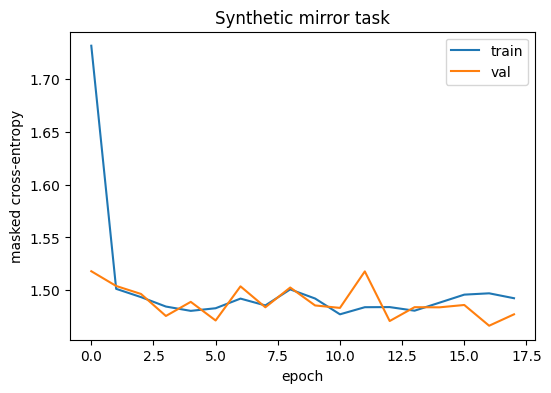

In [40]:

plot_history(syn_history, "Synthetic mirror task")


steps =  1 | exact mirror validity = 0.000
steps =  2 | exact mirror validity = 0.156
steps =  4 | exact mirror validity = 0.584
steps =  8 | exact mirror validity = 1.000
steps = 12 | exact mirror validity = 1.000


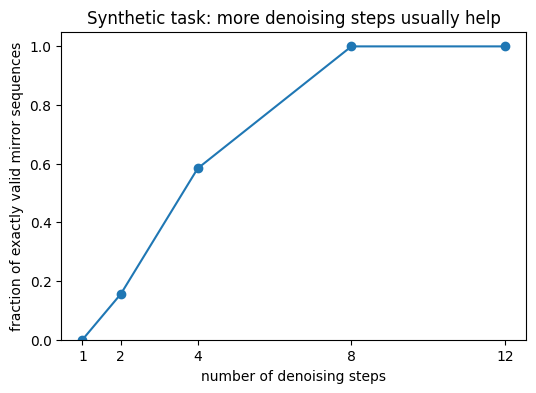

In [41]:

step_grid = [1, 2, 4, 8, 12]
validity = []
num_samples = 100 if FAST_MODE else 500

for steps in step_grid:
    good = 0
    for _ in range(num_samples):
        sample_ids, _ = progressive_unmask_sample(
            syn_model,
            seq_len=SYN_SEQ_LEN,
            mask_id=SYN_MASK_ID,
            steps=steps,
            temperature=1.0,
            greedy=False,
        )
        good += int(mirror_valid(sample_ids.tolist()))
    validity.append(good / num_samples)
    print(f"steps = {steps:2d} | exact mirror validity = {good / num_samples:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(step_grid, validity, marker="o")
plt.xlabel("number of denoising steps")
plt.ylabel("fraction of exactly valid mirror sequences")
plt.title("Synthetic task: more denoising steps usually help")
plt.xticks(step_grid)
plt.ylim(0.0, 1.05)
plt.show()


In [42]:

for steps in [1, 2, 4, 8, 12]:
    sample_ids, _ = progressive_unmask_sample(
        syn_model,
        seq_len=SYN_SEQ_LEN,
        mask_id=SYN_MASK_ID,
        steps=steps,
        temperature=1.0,
        greedy=False,
    )
    print(f"steps = {steps:2d} | {decode_mirror(sample_ids.tolist())} | valid = {mirror_valid(sample_ids.tolist())}")


steps =  1 | 6 5 4 1 6 3 | valid = False
steps =  2 | 6 4 3 6 0 1 | valid = False
steps =  4 | 3 3 7 7 3 3 | valid = True
steps =  8 | 3 0 3 3 0 3 | valid = True
steps = 12 | 6 3 3 3 3 6 | valid = True


In [43]:

_, syn_trace = progressive_unmask_sample(
    syn_model,
    seq_len=SYN_SEQ_LEN,
    mask_id=SYN_MASK_ID,
    steps=8,
    temperature=1.0,
    greedy=False,
)

print("Denoising trajectory for one synthetic sample:\n")
for i, state in enumerate(syn_trace):
    print(f"step {i:02d}: {decode_mirror(state.tolist())}")


Denoising trajectory for one synthetic sample:

step 00: [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]
step 01: [MASK] [MASK] [MASK] [MASK] 3 [MASK]
step 02: 6 3 [MASK] [MASK] 3 [MASK]
step 03: 6 3 [MASK] [MASK] 3 6
step 04: 6 3 [MASK] [MASK] 3 6
step 05: 6 3 [MASK] 3 3 6
step 06: 6 3 [MASK] 3 3 6
step 07: 6 3 [MASK] 3 3 6
step 08: 6 3 3 3 3 6



### Discussion for students

Questions worth asking after the synthetic demo:

- Why is **1-step** generation hard?
- Which positions get fixed earlier during progressive unmasking?
- Why can more steps improve **global consistency** even though the model architecture itself does not change?



# Part 2 — Short text generation with 32-token sequences

For a Mac-friendly demo, we use a compact corpus of **synthetic micro-stories**.

Why not a large real corpus here?

- the notebook stays fully self-contained,
- training stays short enough for a laptop,
- the model can still learn recognizable sentence patterns,
- students can later swap in their own text corpus.

Each training example is exactly **32 tokens**:

- token 0 is **`<bos>`**,
- tokens 1..30 are content words,
- token 31 is **`<eos>`**.


In [44]:

NAMES = ["mira", "leo", "ava", "iris", "milo", "nina", "eli", "tara"]
PLACES = ["the harbor", "the library", "the garden", "the bridge", "the market", "the hill"]
OBJECTS = ["a brass key", "a folded map", "an old clock", "a red kite", "a blue lantern", "a paper boat"]
VERBS = ["found", "carried", "hid", "shared", "followed", "watched"]
GOALS = [
    "before sunset",
    "before dawn",
    "while the town was quiet",
    "under the cold moon",
    "after the long storm",
    "during the morning fog",
]
ADJS = ["quiet", "restless", "curious", "careful", "windy", "gentle"]
FILLERS = [
    "before nightfall",
    "without making a sound",
    "as the street lamps flickered",
    "while the air smelled of rain",
    "because the promise still mattered",
    "until the small mystery opened",
]

TEXT_TEMPLATES = [
    lambda n, p, o, v, g, a: f"{n} {v} {o} near {p} {g} and {n} kept walking because the clue felt {a}",
    lambda n, p, o, v, g, a: f"at dawn {n} carried {o} through {p} hoping to finish a careful plan {g} despite the {a} wind",
    lambda n, p, o, v, g, a: f"near {p} {n} {v} {o} and promised to return it safely {g} after one more {a} detour",
    lambda n, p, o, v, g, a: f"{n} watched the shadows cross {p} with {o} in hand certain a {a} answer would appear {g}",
]


def make_microstory(num_content_words=30):
    n = random.choice(NAMES)
    p = random.choice(PLACES)
    o = random.choice(OBJECTS)
    v = random.choice(VERBS)
    g = random.choice(GOALS)
    a = random.choice(ADJS)

    story = random.choice(TEXT_TEMPLATES)(n, p, o, v, g, a)
    words = story.lower().split()

    while len(words) < num_content_words:
        words += random.choice(FILLERS).lower().split()

    words = words[:num_content_words]
    return " ".join(words)


text_n_stories = 800 if FAST_MODE else 6000
stories = [make_microstory(num_content_words=30) for _ in range(text_n_stories)]

counter = Counter()
for story in stories:
    counter.update(story.split())

TEXT_SPECIALS = ["<bos>", "<eos>", "<mask>"]
text_vocab = TEXT_SPECIALS + sorted(counter.keys())
text_stoi = {token: idx for idx, token in enumerate(text_vocab)}
text_itos = {idx: token for token, idx in text_stoi.items()}

TEXT_BOS = text_stoi["<bos>"]
TEXT_EOS = text_stoi["<eos>"]
TEXT_MASK = text_stoi["<mask>"]
TEXT_SEQ_LEN = 32

print(f"text vocabulary size = {len(text_vocab)}")
print("example training stories:\n")
for story in stories[:3]:
    print("-", story)


text vocabulary size = 109
example training stories:

- near the garden eli carried a blue lantern and promised to return it safely during the morning fog after one more restless detour while the air smelled of rain because
- mira watched the shadows cross the hill with a paper boat in hand certain a careful answer would appear under the cold moon before nightfall without making a sound before
- near the library milo followed a red kite and promised to return it safely before sunset after one more restless detour until the small mystery opened because the promise still


In [45]:

class FixedLengthStoryDataset(Dataset):
    def __init__(self, stories, stoi):
        self.data = []
        for story in stories:
            ids = [stoi["<bos>"]] + [stoi[word] for word in story.split()] + [stoi["<eos>"]]
            assert len(ids) == 32
            self.data.append(torch.tensor(ids, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def decode_story(ids):
    tokens = []
    for idx in ids:
        token = text_itos[int(idx)]
        if token == "<bos>":
            continue
        if token == "<eos>":
            break
        if token == "<mask>":
            tokens.append("[MASK]")
        else:
            tokens.append(token)
    return " ".join(tokens)


split = int(0.90 * len(stories))
text_train = FixedLengthStoryDataset(stories[:split], text_stoi)
text_val = FixedLengthStoryDataset(stories[split:], text_stoi)

text_batch_size = 128
text_epochs = 6 if FAST_MODE else 24
text_d_model = 48 if FAST_MODE else 128
text_layers = 2 if FAST_MODE else 4
text_ff = 96 if FAST_MODE else 256
text_lr = 6e-4 if FAST_MODE else 4e-4

text_train_loader = DataLoader(text_train, batch_size=text_batch_size, shuffle=True)
text_val_loader = DataLoader(text_val, batch_size=128)

text_model = TinyMaskedDiffusionTransformer(
    vocab_size=len(text_vocab),
    seq_len=TEXT_SEQ_LEN,
    d_model=text_d_model,
    n_heads=4,
    n_layers=text_layers,
    d_ff=text_ff,
)

print(f"text model parameters: {count_parameters(text_model):,}")


text model parameters: 579,053


In [46]:

text_history = train_model(
    text_model,
    text_train_loader,
    text_val_loader,
    mask_id=TEXT_MASK,
    epochs=text_epochs,
    lr=text_lr,
    protect_prefix=1,   # keep <bos> visible
)


epoch 01 | train 3.7359 | val 3.0017
epoch 02 | train 2.7230 | val 2.4842
epoch 03 | train 2.3318 | val 2.1490
epoch 04 | train 2.0585 | val 1.9465
epoch 05 | train 1.9005 | val 1.7976
epoch 06 | train 1.7686 | val 1.6872
epoch 07 | train 1.6819 | val 1.5969
epoch 08 | train 1.6380 | val 1.5411
epoch 09 | train 1.5416 | val 1.3951
epoch 10 | train 1.4917 | val 1.3960
epoch 11 | train 1.4415 | val 1.3492
epoch 12 | train 1.3847 | val 1.2838
epoch 13 | train 1.3433 | val 1.3183
epoch 14 | train 1.3106 | val 1.2353
epoch 15 | train 1.2628 | val 1.2487
epoch 16 | train 1.2485 | val 1.2082
epoch 17 | train 1.2233 | val 1.1149
epoch 18 | train 1.2129 | val 1.2142
epoch 19 | train 1.1979 | val 1.1666
epoch 20 | train 1.1968 | val 1.1635
epoch 21 | train 1.1444 | val 1.1722
epoch 22 | train 1.1624 | val 1.1399
epoch 23 | train 1.1648 | val 1.1699
epoch 24 | train 1.1367 | val 1.1655


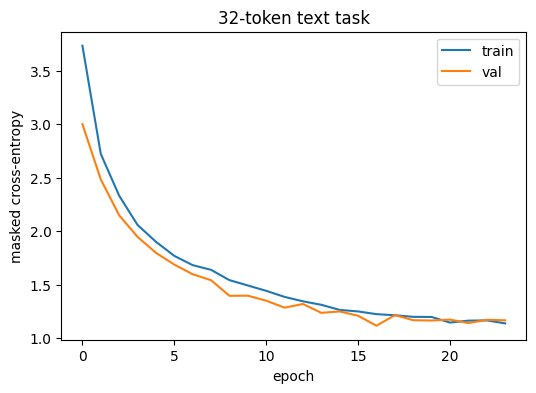

In [47]:

plot_history(text_history, "32-token text task")


In [50]:

for steps in [1, 2, 4, 8, 16, 32]:
    print(f"\n=== generation with {steps} denoising steps ===")
    for _ in range(2):
        sample_ids, _ = progressive_unmask_sample(
            text_model,
            seq_len=TEXT_SEQ_LEN,
            mask_id=TEXT_MASK,
            steps=steps,
            fixed_tokens={0: TEXT_BOS},
            temperature=0.85,
            greedy=False,
        )
        print("-", decode_story(sample_ids.tolist()))



=== generation with 1 denoising steps ===
- iris shared the carried a old clock through a paper clock to hand certain careful gentle answer would the until the town curious the without flickered until as a nightfall
- iris watched the carried cross paper lantern with the promised boat in finish certain a plan answer would appear before one the the while lamps a the the until street

=== generation with 2 denoising steps ===
- nina watched the shadows cross the market with a blue hoping to hand certain a the because would appear before sunset as was until smelled the until the small mystery
- leo watched the shadows cross the market through the red hoping in hand certain kept plan before would appear before sunset while making until the making small opened before nightfall

=== generation with 4 denoising steps ===
- leo watched the shadows cross the the with a folded kite in hand certain a restless answer would appear under the cold moon because the promise still mattered while the
- 

In [49]:

_, text_trace = progressive_unmask_sample(
    text_model,
    seq_len=TEXT_SEQ_LEN,
    mask_id=TEXT_MASK,
    steps=8,
    fixed_tokens={0: TEXT_BOS},
    temperature=0.85,
    greedy=False,
)

print("Denoising trajectory for one text sample:\n")
for i, state in enumerate(text_trace):
    print(f"step {i:02d}: {decode_story(state.tolist())}")


Denoising trajectory for one text sample:

step 00: [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]
step 01: [MASK] [MASK] [MASK] [MASK] cross [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] in [MASK] certain [MASK] [MASK] answer would appear [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]
step 02: [MASK] watched the shadows cross the [MASK] with [MASK] [MASK] [MASK] in hand certain a [MASK] answer would appear [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]
step 03: [MASK] watched the shadows cross the [MASK] with a [MASK] [MASK] in hand certain a [MASK] answer would appear [MASK] the long [MASK] [MASK] the [MASK] [MASK] [MASK] [MASK] the
step 04: [MASK] watched the shadows cross the [MASK] with a [MASK] [MASK] in hand certain a [MASK] answer would appear after the lo


## What students should notice in the text demo

Typical pattern:

- **1 step**: rough bag-of-phrases behavior, weak global consistency.
- **2–4 steps**: stronger sentence template structure starts to appear.
- **8+ steps**: later decisions can use earlier high-confidence words, so the text usually becomes more coherent.

The exact outputs depend on:

- model size,
- dataset size,
- number of epochs,
- temperature,
- denoising schedule.



## Easy extensions for students

1. Change the corruption schedule.
   - Uniform mask ratio is the simplest choice.
   - Try cosine or beta-like schedules.

2. Try a different reverse sampler.
   - Greedy decoding,
   - temperature scaling,
   - top-k or nucleus sampling,
   - different confidence schedules.

3. Swap in a real corpus.
   - Replace the synthetic micro-stories with a small text file.
   - Keep the fixed length at 32 tokens so the rest of the notebook stays simple.

4. Compare against an autoregressive baseline.
   - Same parameter count,
   - same dataset,
   - compare sample quality and speed.

5. Add conditioning.
   - Fix the first few tokens,
   - or add a class label embedding,
   - then study conditional masked diffusion generation.



## References

A good paper trail for students is:

- Jascha Sohl-Dickstein, Eric Weiss, Niru Maheswaranathan, Surya Ganguli. **Deep Unsupervised Learning using Nonequilibrium Thermodynamics**. 2015.
- Emiel Hoogeboom, Didrik Nielsen, Priyank Jaini, Patrick Forré, Max Welling. **Argmax Flows and Multinomial Diffusion: Learning Categorical Distributions**. 2021.
- Jacob Austin, Daniel D. Johnson, Jonathan Ho, Daniel Tarlow, Rianne van den Berg. **Structured Denoising Diffusion Models in Discrete State-Spaces**. 2021.
- Huiwen Chang, Han Zhang, Lu Jiang, Ce Liu, William T. Freeman. **MaskGIT: Masked Generative Image Transformer**. 2022.
- Jiaxin Shi, Kehang Han, Zhe Wang, Arnaud Doucet, Michalis K. Titsias. **Simplified and Generalized Masked Diffusion for Discrete Data**. 2024.
- Subham Sekhar Sahoo, Marianne Arriola, Yair Schiff, Aaron Gokaslan, Edgar Marroquin, Justin T. Chiu, Alexander Rush, Volodymyr Kuleshov. **Simple and Effective Masked Diffusion Language Models**. 2024.

For teaching, it is useful to say explicitly that this notebook is a **small educational implementation**, not a full reproduction of a large-scale research system.
